In [1]:
!pip install PyWavelets

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, iirnotch, filtfilt, welch
import pywt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

# 환경 설정
FS = 1000       # 샘플링 주파수 (1000Hz)
WIN = 300       # 윈도우 크기 (300ms)
HOP = 150       # 홉 크기 (150ms)
SCALES = np.arange(1, 33) # CWT 스케일 32개

# GPU 연결 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 장치: {device}")

사용 중인 장치: cuda


In [2]:
def preprocess(x, fs=FS):
    # 1) 60Hz 전원선 잡음 제거 (노치 필터)
    bn, an = iirnotch(60, 30, fs)
    x = filtfilt(bn, an, x, axis=0)

    # 2) 20~499Hz 대역통과 필터 (4차 버터워스)
    b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
    return filtfilt(b, a, x, axis=0)

# 실행 검증용 더미 데이터 (3000샘플 = 3초, 2채널)
np.random.seed(42)
x_dummy = np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None]
xf_dummy = preprocess(x_dummy)

print("전처리 전 크기:", x_dummy.shape)
print("전처리 후 크기:", xf_dummy.shape)

전처리 전 크기: (3000, 2)
전처리 후 크기: (3000, 2)


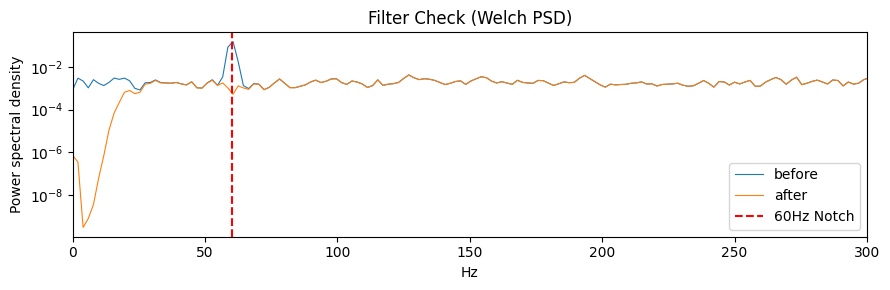

In [3]:
f0, P0 = welch(x_dummy[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf_dummy[:, 0], fs=FS, nperseg=512)

plt.figure(figsize=(9, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--', label='60Hz Notch')
plt.xlim(0, 300)
plt.legend()
plt.xlabel('Hz')
plt.ylabel('Power spectral density')
plt.title('Filter Check (Welch PSD)')
plt.tight_layout()

plt.savefig('filter_check.png', dpi=120)
plt.show()

In [4]:
# 단계 3: 슬라이딩 윈도우 분할
def make_windows(x, win=WIN, hop=HOP):
    n = (len(x) - win) // hop + 1
    return np.stack([x[i*hop : i*hop+win] for i in range(n)])

# 단계 4: Min-Max 정규화 (0~1 지정)
def minmax(w, eps=1e-8):
    mn = w.min(axis=(1,2), keepdims=True)
    mx = w.max(axis=(1,2), keepdims=True)
    return (w - mn) / (mx - mn + eps)

w = make_windows(xf_dummy)
wn = minmax(w)

print('윈도우 분할 배열 모양:', w.shape)
print('정규화 후 최솟값 / 최댓값:', wn.min(), '/', wn.max())

윈도우 분할 배열 모양: (19, 300, 2)
정규화 후 최솟값 / 최댓값: 0.0 / 0.9999999986165474


CWT 변환 텐서 모양 (C, H, W): (3, 32, 300)


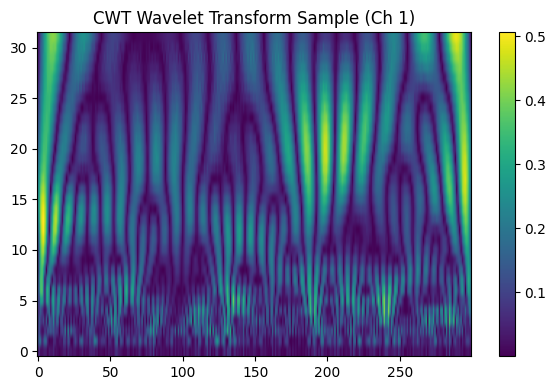

In [5]:
def to_cwt(one_window, wavelet='morl'):
    maps = []
    for ch in range(one_window.shape[1]):
        coef, _ = pywt.cwt(one_window[:, ch], SCALES, wavelet)
        maps.append(np.abs(coef))

    # 3번째 채널은 1,2채널의 평균값으로 채움
    maps.append((maps[0] + maps[1]) / 2)
    return np.stack(maps).astype(np.float32)

t = to_cwt(wn[0])
print('CWT 변환 텐서 모양 (C, H, W):', t.shape)

plt.figure(figsize=(6, 4))
plt.imshow(t[0], aspect='auto', origin='lower')
plt.title("CWT Wavelet Transform Sample (Ch 1)")
plt.colorbar()
plt.tight_layout()

# 이미지 저장 및 표시
plt.savefig('cwt_example.png', dpi=120)
plt.show()

In [8]:
# 더미 데이터 50개 생성 (시행 50개 가정)
dummy_files = [np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None] for _ in range(50)]
dummy_labels = np.random.randint(0, 5, size=50)

# 1) 데이터 누수 방지: 시행(file) 단위로 우선 Train/Test 분할
tr_files, te_files, tr_labels, te_labels = train_test_split(
    dummy_files, dummy_labels, test_size=0.25, stratify=dummy_labels, random_state=42
)

# 2) 전처리 및 CWT 텐서 변환 집계
def build_dataset(flist, llist):
    X, y = [], []
    for sig, lbl in zip(flist, llist):
        sig_p = preprocess(sig)
        for w in minmax(make_windows(sig_p)):
            X.append(to_cwt(w))
            y.append(lbl)
    return np.stack(X), np.array(y)

X_train, y_train = build_dataset(tr_files, tr_labels)
X_test, y_test = build_dataset(te_files, te_labels)

# 파이토치 데이터로더 생성
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

print('최종 학습용 입력 데이터 크기:', X_train.shape)
print('최종 테스트용 입력 데이터 크기:', X_test.shape)

최종 학습용 입력 데이터 크기: (703, 3, 32, 300)
최종 테스트용 입력 데이터 크기: (247, 3, 32, 300)


In [9]:
# 사전학습 미사용 DenseNet161 로드 및 분류기 변경 (5개 클래스)
model = densenet161(weights=None)
model.classifier = nn.Linear(2208, 5)
model.to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

print("GPU 학습 시작...")
# 5에폭 학습 실행 및 Loss 기록 출력
for epoch in range(5):
    model.train()
    tot_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        loss = crit(model(xb), yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tot_loss += loss.item()

    avg_loss = tot_loss / len(train_loader)
    print(f"Epoch {epoch+1}/5 - Loss: {avg_loss:.4f}")

# 가중치 파일 저장
torch.save(model.state_dict(), 'densenet161_model.pth')
print("가중치 저장 완료: densenet161_model.pth")

GPU 학습 시작...
Epoch 1/5 - Loss: 1.7125
Epoch 2/5 - Loss: 1.6366
Epoch 3/5 - Loss: 1.6059
Epoch 4/5 - Loss: 1.5861
Epoch 5/5 - Loss: 1.5653
가중치 저장 완료: densenet161_model.pth


In [10]:
from google.colab import files

# 결과 이미지 파일 PC로 다운로드
files.download('filter_check.png')
files.download('cwt_example.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>